(-0.5, 2591.5, 1943.5, -0.5)

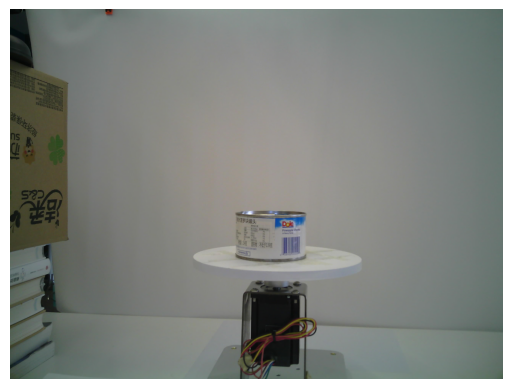

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = os.path.join(DATASET, "train", os.listdir(os.path.join(DATASET, "train"))[0])
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")


In [13]:
import os

BASE_PATH = r"E:\Vista26\Vistas Dataset Public\Vistas Dataset Public"
os.listdir(BASE_PATH)


['background',
 'Categories.json',
 'instances_test.json',
 'instances_train.json',
 'test',
 'train',
 'validation']

In [14]:
import json
import os

BASE_PATH = r"E:\Vista26\Vistas Dataset Public\Vistas Dataset Public"
ANNOTATION_PATH = os.path.join(BASE_PATH, "instances_train.json")

with open(ANNOTATION_PATH, "r") as f:
    data = json.load(f)

print(data.keys())


dict_keys(['images', 'annotations'])


In [15]:
for ann in data["annotations"]:
    if ann["image_id"] == 3:
        print(ann)


{'area': 113598.14, 'bbox': [1171.68, 1047.6, 399.85, 284.1], 'category_id': 112, 'id': 3, 'image_id': 3, 'iscrowd': 0, 'segmentation': [[]], 'point_xy': [1371.61, 1189.65]}


(-0.5, 2591.5, 1943.5, -0.5)

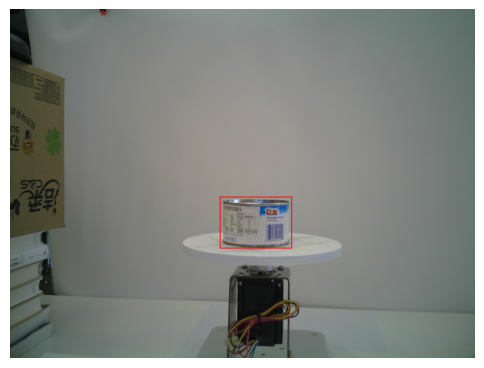

In [2]:
import cv2
import matplotlib.pyplot as plt

# image path
img_path = r"E:\Vista26\Vistas Dataset Public\Vistas Dataset Public\train\038900004095_camera0-10.jpg"

# load image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# bbox from annotation
x, y, w, h = 1171.68, 1047.6, 399.85, 284.1
x, y, w, h = map(int, [x, y, w, h])

# draw bbox
cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 3)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")


In [1]:
from ultralytics import YOLO
print("YOLO ready")


YOLO ready


In [20]:
import numpy as np
np.__version__

'1.26.4'

In [18]:
from ultralytics import YOLO
print("Ultralytics working 🚀")


Ultralytics working 🚀


In [1]:
import torch
print(torch.__version__)

2.1.2+cu118


In [2]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # or your trained weights


In [7]:
print(model.names)


{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [3]:
import cv2

img_path = r"E:\vista26\Vistas Dataset Public\Vistas Dataset Public\test\20180824-13-35-55-2.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


(-0.5, 1833.5, 1833.5, -0.5)

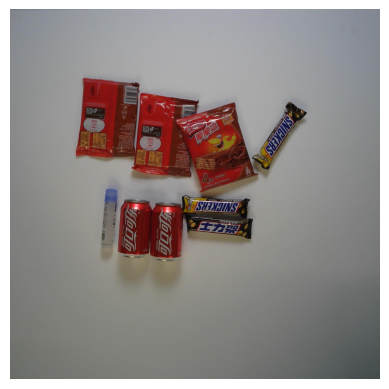

In [4]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")

In [7]:
import os
import json
from tqdm import tqdm
import shutil

BASE_PATH = r"E:\Vista26\Vistas Dataset Public\Vistas Dataset Public"

IMAGE_DIR = os.path.join(BASE_PATH, "train")
ANNOTATION_FILE = os.path.join(BASE_PATH, "instances_train.json")

YOLO_BASE = r"E:\Vista26\yolo_dataset"
YOLO_IMG_DIR = os.path.join(YOLO_BASE, "images", "train")
YOLO_LBL_DIR = os.path.join(YOLO_BASE, "labels", "train")

os.makedirs(YOLO_IMG_DIR, exist_ok=True)
os.makedirs(YOLO_LBL_DIR, exist_ok=True)


In [8]:
with open(ANNOTATION_FILE, "r") as f:
    data = json.load(f)

images = {img["id"]: img for img in data["images"]}
annotations = data["annotations"]

print("Total images:", len(images))
print("Total annotations:", len(annotations))


Total images: 53739
Total annotations: 53739


In [9]:
for ann in tqdm(annotations):
    image_id = ann["image_id"]
    img_info = images[image_id]

    img_name = img_info["file_name"]
    img_w = img_info["width"]
    img_h = img_info["height"]

    # COCO bbox
    x, y, w, h = ann["bbox"]

    # Convert to YOLO format
    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    w_norm = w / img_w
    h_norm = h / img_h

    # YOLO class index (0-based!)
    class_id = ann["category_id"] - 1

    label_path = os.path.join(
        YOLO_LBL_DIR,
        os.path.splitext(img_name)[0] + ".txt"
    )

    with open(label_path, "a") as f:
        f.write(f"{class_id} {x_center} {y_center} {w_norm} {h_norm}\n")

    # Copy image once
    src_img = os.path.join(IMAGE_DIR, img_name)
    dst_img = os.path.join(YOLO_IMG_DIR, img_name)

    if not os.path.exists(dst_img):
        shutil.copy(src_img, dst_img)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53739/53739 [00:49<00:00, 1085.15it/s]


In [10]:
print("Sample label files:", os.listdir(YOLO_LBL_DIR)[:5])
print("Sample image files:", os.listdir(YOLO_IMG_DIR)[:5])

sample_lbl = os.listdir(YOLO_LBL_DIR)[0]
with open(os.path.join(YOLO_LBL_DIR, sample_lbl)) as f:
    print(sample_lbl, "->", f.read())


Sample label files: ['038900004095_camera0-10.txt', '038900004095_camera0-11.txt', '038900004095_camera0-12.txt', '038900004095_camera0-13.txt', '038900004095_camera0-14.txt']
Sample image files: ['038900004095_camera0-10.jpg', '038900004095_camera0-11.jpg', '038900004095_camera0-12.jpg', '038900004095_camera0-13.jpg', '038900004095_camera0-14.jpg']
038900004095_camera0-10.txt -> 111 0.5291685956790123 0.6119598765432098 0.15426311728395062 0.14614197530864198
111 0.5291685956790123 0.6119598765432098 0.15426311728395062 0.14614197530864198



In [11]:
import json
import os

BASE_PATH = r"E:\Vista26\Vistas Dataset Public\Vistas Dataset Public"
CAT_FILE = os.path.join(BASE_PATH, "Categories.json")

with open(CAT_FILE, "r") as f:
    cats = json.load(f)

print(type(cats))
print(cats.keys())



<class 'dict'>
dict_keys(['categories', '__raw_Chinese_name_df'])


In [12]:
# cats is already loaded JSON dict
categories = cats["categories"]

# sort by id (VERY important)
categories = sorted(categories, key=lambda x: x["id"])

# extract class names
class_names = [c["name"] for c in categories]

print("Total classes:", len(class_names))
print("First 5 classes:", class_names[:5])
print("Last 5 classes:", class_names[-5:])


Total classes: 200
First 5 classes: ['1_puffed_food', '2_puffed_food', '3_puffed_food', '4_puffed_food', '5_puffed_food']
Last 5 classes: ['196_stationery', '197_stationery', '198_stationery', '199_stationery', '200_stationery']


In [13]:
import yaml
import os

YOLO_BASE = r"E:\Vista26\yolo_dataset"

data_yaml = {
    "path": YOLO_BASE,
    "train": "images/train",
    "val": "images/train",  # temporary, ok for now
    "nc": 200,
    "names": class_names
}

yaml_path = os.path.join(YOLO_BASE, "data.yaml")
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("data.yaml created at:", yaml_path)


data.yaml created at: E:\Vista26\yolo_dataset\data.yaml


In [14]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [15]:
import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")  # nano model (fast & safe)

model.train(
    data=r"E:\Vista26\yolo_dataset\data.yaml",
    epochs=5,
    imgsz=640,
    batch=8,
    workers=4
)


New https://pypi.org/project/ultralytics/8.4.9 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.47  Python-3.10.19 torch-2.1.2+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=E:\Vista26\yolo_dataset\data.yaml, epochs=5, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=4, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False,

train: Scanning E:\vista26\yolo_dataset\labels\train.cache... 53739 images, 0 backgrounds, 0 corrupt: 100%|██████████| 53739/53739 [00:00<?, ?it/s]IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)


val: Scanning E:\vista26\yolo_dataset\labels\train.cache... 53739 images, 0 backgrounds, 0 corrupt: 100%|██████████| 53739/53739 [00:00<?, ?it/s]IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)




Plotting labels to runs\detect\train5\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=4.9e-05, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to runs\detect\train5
Starting training for 5 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/5      1.89G     0.6548      4.783     0.9797          5        640: 100%|██████████| 6718/6718 [23:07<00:00,  4.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3359/3359 [12:03<00:00,  4.64it/s]


                   all      53739      53739      0.195      0.358      0.207      0.191

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

        5/5         2G     0.4629      1.238     0.8919          3        640: 100%|██████████| 6718/6718 [20:49<00:00,  5.38it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3359/3359 [11:52<00:00,  4.72it/s]


                   all      53739      53739      0.929       0.94      0.963      0.906

5 epochs completed in 2.790 hours.
Optimizer stripped from runs\detect\train5\weights\last.pt, 7.0MB
Optimizer stripped from runs\detect\train5\weights\best.pt, 7.0MB

Validating runs\detect\train5\weights\best.pt...
Ultralytics YOLOv8.1.47  Python-3.10.19 torch-2.1.2+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 168 layers, 3371024 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3359/3359 [12:05<00:00,  4.63it/s]


                   all      53739      53739      0.929       0.94      0.963      0.906
         1_puffed_food      53739        320      0.973          1      0.995       0.97
         2_puffed_food      53739        320      0.999          1      0.995      0.965
         3_puffed_food      53739        320          1      0.941      0.995      0.956
         4_puffed_food      53739        320      0.979      0.997      0.995      0.969
         5_puffed_food      53739        320      0.996          1      0.995      0.966
         6_puffed_food      53739        320      0.946      0.994      0.994      0.975
         7_puffed_food      53739        320      0.997          1      0.995      0.995
         8_puffed_food      53739        320      0.998          1      0.995      0.985
         9_puffed_food      53739        320       0.98          1      0.995      0.991
        10_puffed_food      53739        320      0.991          1      0.995      0.974
        11_puffed_foo

ModuleNotFoundError: No module named 'scipy'

In [4]:
import os
import json
import pandas as pd
from ultralytics import YOLO

# =======================
# PATHS (UPDATED)
# =======================
VAL_JSON = r"E:\vista26\instances_val.json"
VAL_IMG_DIR = r"E:\Vista26\Vistas Dataset Public\Vistas Dataset Public\validation"
MODEL_PATH = r"runs/detect/train5/weights/best.pt"

CONF_THRESHOLD = 0.25

# =======================
# LOAD VALIDATION METADATA
# =======================
with open(VAL_JSON, "r") as f:
    val_data = json.load(f)

images = val_data["images"]
print("Validation images found:", len(images))

# MUST BE 6000
assert len(images) == 6000, "Validation image count is NOT 6000!"

# =======================
# LOAD MODEL
# =======================
model = YOLO(MODEL_PATH)

# =======================
# GENERATE SUBMISSION
# =======================
rows = []

for img in images:
    image_id = img["id"]
    img_path = os.path.join(VAL_IMG_DIR, img["file_name"])

    results = model(img_path, conf=CONF_THRESHOLD, device=0, verbose=False)

    if results[0].boxes is None:
        categories = []
    else:
        preds = results[0].boxes.cls.tolist()
        categories = sorted(set(int(c) + 1 for c in preds))  # 1-based

    rows.append({
        "image_id": image_id,
        "categories": json.dumps(categories)
    })

# =======================
# CREATE CSV (STRICT SORTING)
# =======================
df = pd.DataFrame(rows)
df = df.sort_values("image_id").reset_index(drop=True)

assert len(df) == 6000
assert df["image_id"].is_monotonic_increasing

df.to_csv("submission.csv", index=False)

print("✅ submission.csv generated successfully!")
print("Total rows:", len(df))
print(df.head())


Validation images found: 6000
✅ submission.csv generated successfully!
Total rows: 6000
   image_id categories
0        10      [124]
1        12       [21]
2        14       [48]
3        17         []
4        18      [184]


In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train5/weights/best.pt")

results = model("test.jpg")

results[0].show()